<h1><center>EE69210: Machine Learning for Signal Processing Laboratory</center></h1>
<h2><center>Experiment-10: Speech Gender Recognition using Neural Networks </center></h2>
<h3><center>Anirvan Krishna | 21EE38002</center></h3>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import OrderedDict
from torchsummary import summary
import torch.nn.functional as F
import seaborn as sns
import glob
import os
import librosa

from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Speech Feature Extraction

In [2]:
def extract_feature(file_name, **kwargs):

    mfcc = kwargs.get("mfcc")
    mel = kwargs.get("mel")
    X, sample_rate = librosa.core.load(file_name)
    
    result = np.array([])
    if mfcc:
        mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
        result = np.hstack((result, mfccs))
    
    if mel:
        mel = np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T, axis=0)
        result = np.hstack((result, mel))
    
    return result

## Data Preprocessing

In [ ]:
dirname = "new_data"
if not os.path.isdir(dirname):
    os.mkdir(dirname)

csv_files = glob.glob("*.csv")
for j, csv_file in enumerate(csv_files):
    print("[+] Preprocessing", csv_file)
    df = pd.read_csv(csv_file)
    # only take filename and gender columns
    new_df = df[["filename", "gender"]]
    print(f"Previously {len(new_df)} rows")
    # take only male and female genders
    new_df = new_df[np.logical_or(
        new_df["gender"] == "female", new_df["gender"] == "male")]
    # 0 label for male, 1 for female
    new_df.loc[df["gender"] == "male", "gender"] = 0
    new_df.loc[df["gender"] == "female", "gender"] = 1
    print(f"Now {len(new_df)} rows")
    new_csv_file = os.path.join(dirname, csv_file)
    # save new preprocessed CSV
    new_df.to_csv(new_csv_file, index=False)
    # get the folder name
    folder_name, _ = csv_file.split(".")
    audio_files = glob.glob(f"{folder_name}/{folder_name}/*")
    all_audio_filenames = set(new_df["filename"])
    for i, audio_file in tqdm(list(enumerate(audio_files)), f"Extracting features of {folder_name}"):
        splited = os.path.split(audio_file)
        audio_filename = f"{os.path.split(splited[0])[-1]}/{splited[-1]}"
        if audio_filename in all_audio_filenames:
            src_path = f"{folder_name}/{audio_filename}"
            target_path = f"{dirname}/{audio_filename}"
            # create that folder if it doesn't exist
            if not os.path.isdir(os.path.dirname(target_path)):
                os.mkdir(os.path.dirname(target_path))
            features = extract_features(src_path, mel=True, mfcc=True)
            target_filename = target_path.split(".")[0]
            np.save(target_filename, features)

train_csv_path = "/kaggle/input/mlsp-exp10-csv/cv-valid-train.csv"
test_csv_path = "/kaggle/input/mlsp-exp10-csv/cv-valid-test.csv"
dev_csv_path = "/kaggle/input/mlsp-exp10-csv/cv-valid-dev.csv"

# Read CSV files
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
dev_df = pd.read_csv(dev_csv_path)

# Change file extension from .mp3 to .npy and add a prefix
train_df['filename'] = 'new_data/' + \
    train_df['filename'].str.replace('.mp3', '.npy')
test_df['filename'] = 'new_data/' + \
    test_df['filename'].str.replace('.mp3', '.npy')
dev_df['filename'] = 'new_data/' + \
    dev_df['filename'].str.replace('.mp3', '.npy')

# Concatenate dataframes without preserving original indices
combined_df = pd.concat([train_df, test_df, dev_df], ignore_index=True)

# Save the final DataFrame
combined_df.to_csv("balanced-all.csv", index=False)


In [4]:
from sklearn.model_selection import train_test_split

# Load the balanced data
balanced_df = pd.read_csv("/kaggle/input/mlsp10/balanced-all.csv")

def update_path(path):
    # Extracts folder name (e.g., cv-valid-train) from the path
    folder = path.split('/')[1]
    return f"/kaggle/input/mlsp10/new_data/new_data/{folder}/" + os.path.basename(path)

balanced_df['filename'] = balanced_df['filename'].apply(update_path)


# Display the first few rows to understand the data
print(f"Total samples: {len(balanced_df)}")
print(balanced_df.head())

# Check for class distribution
print("\nGender distribution:")
print(balanced_df['gender'].value_counts())

# First, split into train and temp 
train_df, temp_df = train_test_split(balanced_df, test_size=0.2, random_state=42, stratify=balanced_df['gender'])

# Split temp into val and test 
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['gender'])

print(f"\nTrain set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

# Verify class distribution in each split
print("\nClass distribution in train set:")
print(train_df['gender'].value_counts())
print("\nClass distribution in validation set:")
print(val_df['gender'].value_counts())
print("\nClass distribution in test set:")
print(test_df['gender'].value_counts())

Total samples: 76336
                                            filename  gender
0  /kaggle/input/mlsp10/new_data/new_data/cv-vali...       1
1  /kaggle/input/mlsp10/new_data/new_data/cv-vali...       0
2  /kaggle/input/mlsp10/new_data/new_data/cv-vali...       1
3  /kaggle/input/mlsp10/new_data/new_data/cv-vali...       0
4  /kaggle/input/mlsp10/new_data/new_data/cv-vali...       0

Gender distribution:
gender
0    57301
1    19035
Name: count, dtype: int64

Train set: 61068 samples
Validation set: 7634 samples
Test set: 7634 samples

Class distribution in train set:
gender
0    45840
1    15228
Name: count, dtype: int64

Class distribution in validation set:
gender
0    5730
1    1904
Name: count, dtype: int64

Class distribution in test set:
gender
0    5731
1    1903
Name: count, dtype: int64


Male sample: /kaggle/input/mlsp10/new_data/new_data/cv-valid-train/sample-185994.npy
Female sample: /kaggle/input/mlsp10/new_data/new_data/cv-valid-train/sample-137222.npy


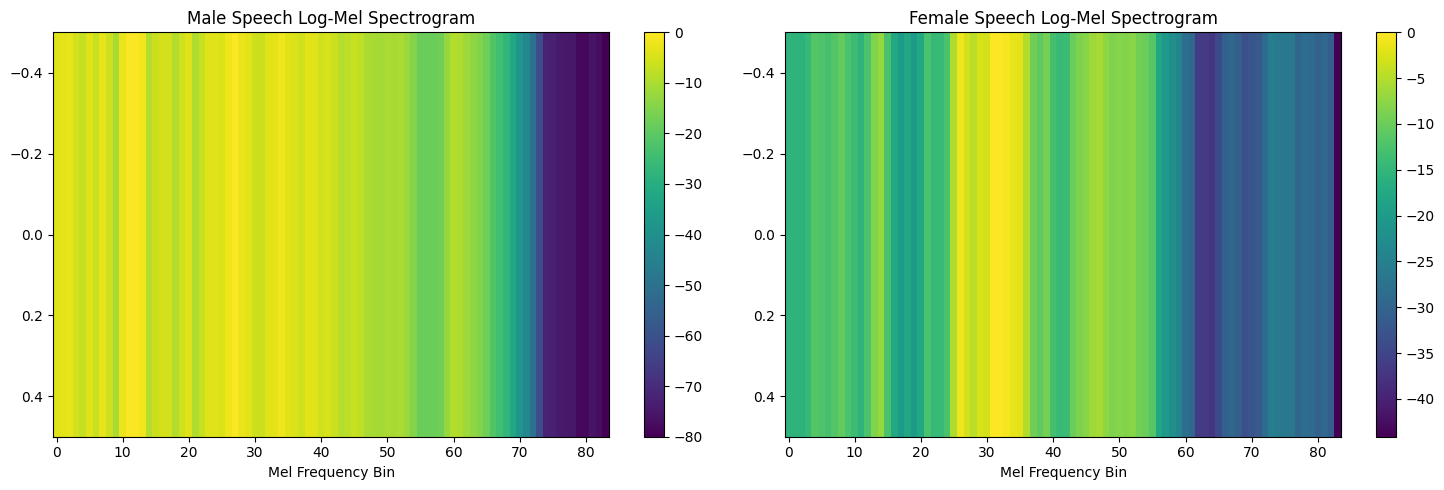

In [5]:
def generate_mel_spectrogram(file_path):
    features = np.load(file_path)
    
    feature_length = len(features)
    mel_features = features[feature_length//2:] if feature_length > 128 else features
    
    log_mel = librosa.power_to_db(mel_features, ref=np.max)
    
    return log_mel

male_sample = train_df[train_df['gender'] == 0]['filename'].iloc[0]
female_sample = train_df[train_df['gender'] == 1]['filename'].iloc[0]

print(f"Male sample: {male_sample}")
print(f"Female sample: {female_sample}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

male_mel = generate_mel_spectrogram(male_sample)
im0 = axes[0].imshow(male_mel.reshape(1, -1), aspect='auto', cmap='viridis')
axes[0].set_title('Male Speech Log-Mel Spectrogram')
axes[0].set_xlabel('Mel Frequency Bin')
fig.colorbar(im0, ax=axes[0], orientation='vertical')

female_mel = generate_mel_spectrogram(female_sample)
im1 = axes[1].imshow(female_mel.reshape(1, -1), aspect='auto', cmap='viridis')
axes[1].set_title('Female Speech Log-Mel Spectrogram')
axes[1].set_xlabel('Mel Frequency Bin')
fig.colorbar(im1, ax=axes[1], orientation='vertical')

plt.tight_layout()
plt.show()

Using device: cuda
Input batch shape: torch.Size([128, 168])
Label batch shape: torch.Size([128])
Sample file: /kaggle/input/mlsp10/new_data/new_data/cv-valid-train/sample-137222.npy
Feature shape: (168,)
Total feature length: 168
First half (MFCC) shape: (84,)
Second half (Mel) shape: (84,)


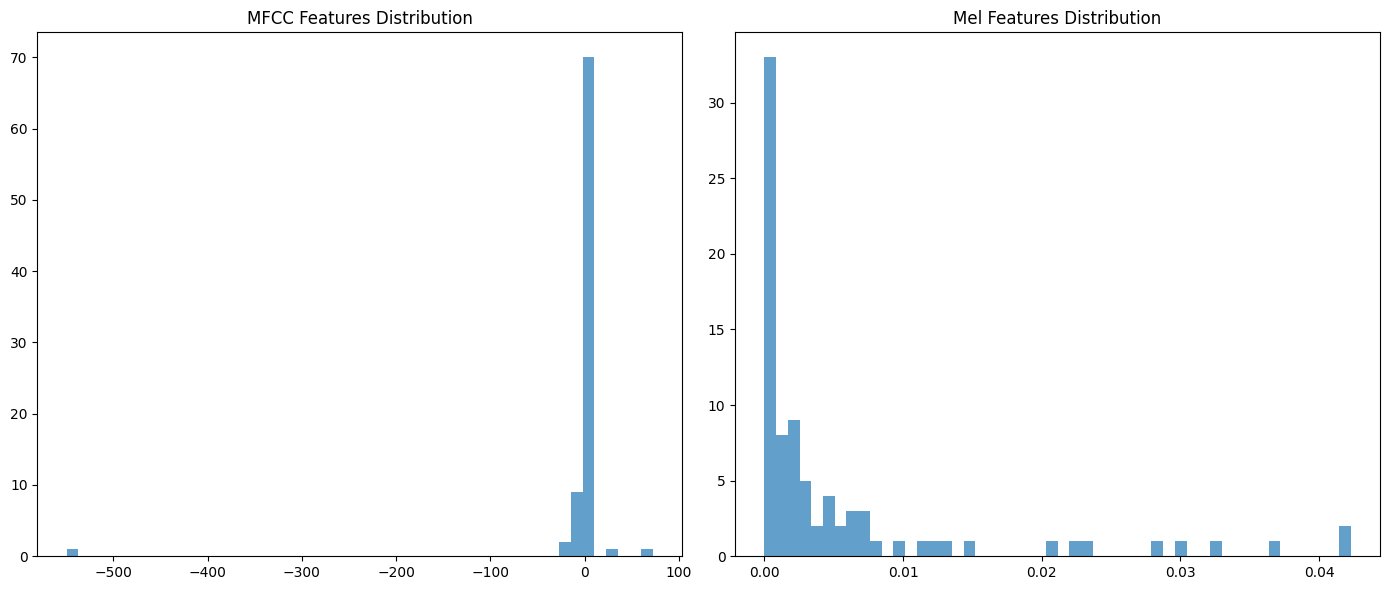

In [6]:
# Create a PyTorch dataset for loading speech data
class SpeechDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        # Get the file path and label
        file_path = self.dataframe.iloc[index]['filename']
        label = self.dataframe.iloc[index]['gender']
        
        # Load the features
        features = np.load(file_path)
        
        # Convert to tensor
        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32)
        
        return features, label

# Create the datasets and dataloaders
train_dataset = SpeechDataset(train_df)
val_dataset = SpeechDataset(val_df)
test_dataset = SpeechDataset(test_df)

# Define batch size
batch_size = 128

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True,
                                           num_workers=4,
                                           pin_memory=True if torch.cuda.is_available() else False)

val_loader = torch.utils.data.DataLoader(val_dataset, 
                                         batch_size=batch_size, 
                                         shuffle=False, num_workers=4,
                                         pin_memory=True if torch.cuda.is_available() else False)

test_loader = torch.utils.data.DataLoader(test_dataset,
                                           batch_size=batch_size, 
                                          shuffle=False, num_workers=4,
                                          pin_memory=True if torch.cuda.is_available() else False)

# Check a batch from the training loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Get a sample batch
inputs, labels = next(iter(train_loader))
print(f"Input batch shape: {inputs.shape}")
print(f"Label batch shape: {labels.shape}")

# Load and analyze feature shape from a sample file
sample_file = train_df['filename'].iloc[0]
features = np.load(sample_file)

print(f"Sample file: {sample_file}")
print(f"Feature shape: {features.shape}")

# Split the features to understand their structure
feature_length = len(features)
print(f"Total feature length: {feature_length}")

# If the features are concatenated (MFCC + Mel), analyze them separately
if feature_length > 128:  # Assuming we have both MFCC and Mel features
    mfcc_features = features[:feature_length//2]
    mel_features = features[feature_length//2:]
    print(f"First half (MFCC) shape: {mfcc_features.shape}")
    print(f"Second half (Mel) shape: {mel_features.shape}")
    
    # Visualize distribution of feature values
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.hist(mfcc_features, bins=50, alpha=0.7)
    plt.title('MFCC Features Distribution')
    
    plt.subplot(1, 2, 2)
    plt.hist(mel_features, bins=50, alpha=0.7)
    plt.title('Mel Features Distribution')
    plt.tight_layout()
    plt.show()

## Neural Network Model

In [7]:
class SpeechGenderModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SpeechGenderModel, self).__init__()
        
        self.layers = nn.Sequential(OrderedDict([
            # Dense 1
            ('fc1', nn.Linear(input_size, 256)),
            ('dropout1', nn.Dropout(p=0.3)),
            
            # Dense 2
            ('fc2', nn.Linear(256, 256)),
            ('relu2', nn.ReLU()),
            ('dropout2', nn.Dropout(p=0.3)),
            
            # Dense 3
            ('fc3', nn.Linear(256, 128)),
            ('relu3', nn.ReLU()),
            ('dropout3', nn.Dropout(p=0.3)),
            
            # Dense 4
            ('fc4', nn.Linear(128, 128)),
            ('relu4', nn.ReLU()),
            ('dropout4', nn.Dropout(p=0.3)),
            
            # Dense 5
            ('fc5', nn.Linear(128, 64)),
            ('relu5', nn.ReLU()),
            ('dropout5', nn.Dropout(p=0.3)),
            
            # Output
            ('output', nn.Linear(64, num_classes)),
            ('sigmoid', nn.Sigmoid())
        ]))
    
    def forward(self, x):
        return self.layers(x)

In [8]:
model = SpeechGenderModel(input_size=168, num_classes=2).to(device)
summary(model=model, input_size=(168,), batch_size=batch_size, device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [128, 256]          43,264
           Dropout-2                 [128, 256]               0
            Linear-3                 [128, 256]          65,792
              ReLU-4                 [128, 256]               0
           Dropout-5                 [128, 256]               0
            Linear-6                 [128, 128]          32,896
              ReLU-7                 [128, 128]               0
           Dropout-8                 [128, 128]               0
            Linear-9                 [128, 128]          16,512
             ReLU-10                 [128, 128]               0
          Dropout-11                 [128, 128]               0
           Linear-12                  [128, 64]           8,256
             ReLU-13                  [128, 64]               0
          Dropout-14                  [

In [9]:
def test_model(model, dataloader, criterion, device):
    
    model.eval()
    test_accuracy = []
    test_losses = []

    with torch.no_grad(): 
        for test_img, test_label in dataloader:
            test_img, test_label = test_img.to(device), test_label.long().to(device)
            test_out = model(test_img)
            
            # Compute loss
            loss = criterion(test_out, test_label)
            test_losses.append(loss.item())

            # Compute accuracy
            _, test_out = torch.max(test_out, 1)
            test_acc = (torch.sum(test_out == test_label).item() / test_label.size(0))
            test_accuracy.append(test_acc)
       
    mean_accuracy = sum(test_accuracy) / len(test_accuracy)
    mean_loss = sum(test_losses) / len(test_losses)

    return mean_loss, mean_accuracy


In [10]:
def train(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10):
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    train_accuracies = []

    for epoch in range(n_epochs):
        
        model.train()
        
        print(
        f'=====================================[Epoch: {epoch+1}/{n_epochs}]=========================================\n'
        )
        
        loss_train = 0
        train_accuracy = []

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device).long()

            optimizer.zero_grad()
            preds = model(images)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

            # Accumulate loss
            loss_train += loss.item() * images.size(0)

            # Compute accuracy per batch
            _, predicted = torch.max(preds, 1)
            batch_acc = (torch.sum(predicted == labels).item() / labels.size(0)) 
            train_accuracy.append(batch_acc)

        # Compute mean accuracy & loss
        loss_train /= len(train_loader.dataset)
        mean_train_accuracy = sum(train_accuracy) / len(train_accuracy)

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_loss, val_accuracy = test_model(model, val_loader, criterion, device)
            
        train_losses.append(loss_train)
        train_accuracies.append(mean_train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
    
        print(f"Train Loss: {loss_train:.4f}\tTrain Accuracy: {mean_train_accuracy*100:.2f} %\nVal Loss: {val_loss:.4f}\tVal Accuracy: {val_accuracy*100:.2f} %\n")
        print("_"*100)

    return train_losses, val_losses, train_accuracies, val_accuracies


In [17]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    
    fig, axs = plt.subplots(1, 2, figsize=(20, 5))

    axs[0].plot(train_losses, label='Train Loss', color='blue')
    axs[0].plot(val_losses, label='Validation Loss', color='red')
    axs[0].set_title('Loss Plots')
    axs[0].legend()

    axs[1].plot(train_accuracies, label='Train Accuracy', color='blue')
    axs[1].plot(val_accuracies, label='Validation Accuracy', color='red')
    axs[1].set_title('Accuracy Plots')
    axs[1].legend()

    plt.show()

def test_metrics(model, test_loader):
    """
    Plot confusion matrix and classification report on the test loader
    """

    y_true = []
    y_pred = []

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).long()

        preds = model(images)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.argmax(1).cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"Classification Report: \n{classification_report(y_true, y_pred)}")

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 8))
   
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax)

In [12]:
model = SpeechGenderModel(input_size=168, num_classes=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-04)
num_epochs = 100
criterion = nn.CrossEntropyLoss()

train_losses, val_losses, train_accuracies, val_accuracies = train(
    model, train_loader, val_loader, optimizer, criterion, device, n_epochs=num_epochs
)

=====================================[Epoch: 1/100]=========================================



100%|██████████| 478/478 [01:07<00:00,  7.09it/s]


Train Loss: 0.5229	Train Accuracy: 78.87 %
Val Loss: 0.4058	Val Accuracy: 90.50 %

____________________________________________________________________________________________________
=====================================[Epoch: 2/100]=========================================



100%|██████████| 478/478 [00:18<00:00, 25.85it/s]


Train Loss: 0.4047	Train Accuracy: 90.64 %
Val Loss: 0.3959	Val Accuracy: 91.45 %

____________________________________________________________________________________________________
=====================================[Epoch: 3/100]=========================================



...

Train Loss: 0.3490	Train Accuracy: 96.29 %
Val Loss: 0.3505	Val Accuracy: 96.14 %

____________________________________________________________________________________________________
=====================================[Epoch: 99/100]=========================================



100%|██████████| 478/478 [00:17<00:00, 26.68it/s]


Train Loss: 0.3479	Train Accuracy: 96.43 %
Val Loss: 0.3506	Val Accuracy: 95.98 %

____________________________________________________________________________________________________
=====================================[Epoch: 100/100]=========================================



100%|██████████| 478/478 [00:18<00:00, 25.61it/s]


Train Loss: 0.3482	Train Accuracy: 96.40 %
Val Loss: 0.3504	Val Accuracy: 96.23 %

____________________________________________________________________________________________________


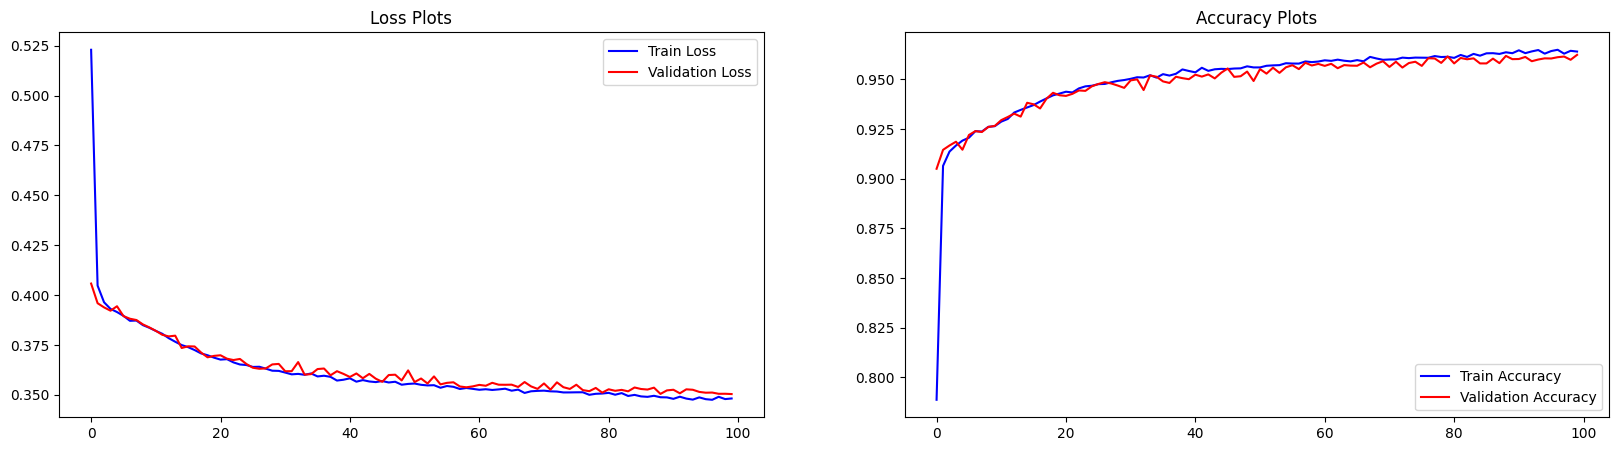

In [13]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5731
           1       0.92      0.93      0.93      1903

    accuracy                           0.96      7634
   macro avg       0.95      0.95      0.95      7634
weighted avg       0.96      0.96      0.96      7634



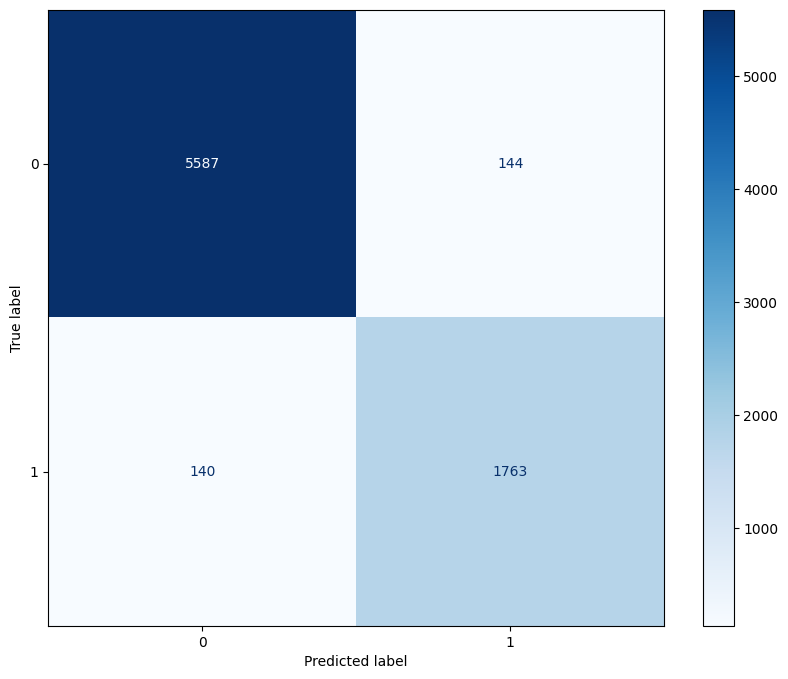

In [18]:
test_metrics(model, test_loader)